In [27]:
from google.colab import files
uploaded = files.upload()

Saving Student_Projects.zip to Student_Projects.zip


In [28]:
import zipfile

with zipfile.ZipFile("Student_Projects.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [29]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1"

import tensorflow as tf
print(f"TensorFlow Version {tf.__version__} loaded.")
print("Intel oneDNN optimizations ENABLED for Deep Learning.")

!pip install scikit-learn-intelex -q
from sklearnex import patch_sklearn
patch_sklearn()
print("Intel oneDAL optimizations ENABLED for Data Metrics.")

TensorFlow Version 2.19.0 loaded.
Intel oneDNN optimizations ENABLED for Deep Learning.
Intel oneDAL optimizations ENABLED for Data Metrics.


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [31]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_PATH = "/content/dataset"

In [32]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 193 files belonging to 3 classes.
Using 155 files for training.


In [33]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 193 files belonging to 3 classes.
Using 38 files for validation.


In [34]:
class_names = train_ds.class_names
print(f"Detected Classes: {class_names}")

Detected Classes: ['CELOSIA ARGENTEA L', 'CROWFOOT GRASS', 'PURPLE CHLORIS']


In [35]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [36]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

In [37]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

In [38]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

In [39]:
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)
model.save("plant_model.keras")

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 430ms/step - accuracy: 0.6387 - loss: 0.8732 - val_accuracy: 0.8421 - val_loss: 0.3209
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8903 - loss: 0.2581 - val_accuracy: 0.9474 - val_loss: 0.1206
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9419 - loss: 0.1867 - val_accuracy: 0.9737 - val_loss: 0.0944
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9742 - loss: 0.0613 - val_accuracy: 0.9737 - val_loss: 0.1313
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9742 - loss: 0.0621 - val_accuracy: 0.9737 - val_loss: 0.0604
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9935 - loss: 0.0283 - val_accuracy: 1.0000 - val_loss: 0.0373
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9935 - loss: 0.0265 - val_accuracy: 0.9737 - val_loss: 0.0467
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0166 - val_accuracy: 0.9737 - val_loss: 0.0555

In [41]:
PLANT_DATABASE = {
    "CROWFOOT GRASS": {
        "type": "Weed",
        "risk": "High (Resource Theft & Rapid Spread)",
        "threat_details": "Highly competitive root system. Aggressively steals soil moisture and vital nutrients (like nitrogen) away from your main crops, directly reducing your harvest yield.",
        "advice": "Use targeted post-emergence herbicide. Remove manually before it drops seeds."
    },
    "PURPLE CHLORIS": {
        "type": "Weed",
        "risk": "High (Invasive & Hard to Eradicate)",
        "threat_details": "Spreads very rapidly via wind-blown seeds. Known to develop resistance to standard herbicides and thrives even in poor soil conditions.",
        "advice": "Manual removal recommended early on. If widespread, consult agronomist for specific herbicide rotation."
    },
    "CELOSIA ARGENTEA L": {
        "type": "Useful Plant / Flower",
        "risk": "Low (Benign / Beneficial) 🌿",
        "threat_details": "No threat to crops. It actually attracts helpful pollinators to the farm and can be harvested as an ornamental flower or for traditional medicine.",
        "advice": "Safe to keep. Let it grow to support farm biodiversity."
    }
}

In [42]:
def predict_with_advice(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    label = class_names[class_idx]
    confidence = np.max(pred) * 100

    print(f"\n--- DIAGNOSIS REPORT ---")
    print(f"Prediction: {label} ({confidence:.2f}% confidence)")

    info = PLANT_DATABASE.get(label, {
        "type": "Unknown",
        "risk": "Unknown",
        "threat_details": "No data available.",
        "advice": "Consult local agronomist."
    })

    print(f"Type: {info['type']}")
    print(f"Risk Level: {info['risk']}")
    print(f"Why it matters: {info['threat_details']}")
    print(f"Action Plan: {info['advice']}")
    print("------------------------\n")

    return label

In [47]:
def get_gradcam(img_path, alpha=0.4):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    base_model_layer = None
    for layer in model.layers:
        if "mobilenet" in layer.name.lower():
            base_model_layer = layer
            break

    if base_model_layer is None:
        print("Error: Could not find base model.")
        return

    last_conv_layer = base_model_layer.get_layer('out_relu')

    inner_grad_model = tf.keras.Model(
        inputs=base_model_layer.inputs,
        outputs=[last_conv_layer.output, base_model_layer.output]
    )

    processed_img = preprocess_input(np.copy(img_array))

    base_idx = model.layers.index(base_model_layer)

    with tf.GradientTape() as tape:
        conv_outputs, base_predictions = inner_grad_model(processed_img)
        tape.watch(conv_outputs)

        x = base_predictions
        for layer in model.layers[base_idx+1:]:
            x = layer(x)
        predictions = x

        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    original_img = cv2.imread(img_path)
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    superimposed_img = heatmap_colored * alpha + original_img

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.title(f"Explainable AI: Why it chose {class_names[class_idx.numpy()]}")
    plt.axis('off')
    plt.show()

Running Prediction & Farm Advisor Logic...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

--- DIAGNOSIS REPORT ---
Prediction: CROWFOOT GRASS (99.76% confidence)
Type: Weed
Risk Level: High (Resource Theft & Rapid Spread)
Why it matters: Highly competitive root system. Aggressively steals soil moisture and vital nutrients (like nitrogen) away from your main crops, directly reducing your harvest yield.
Action Plan: Use targeted post-emergence herbicide. Remove manually before it drops seeds.
------------------------

Generating Explainable AI Heatmap...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_165']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


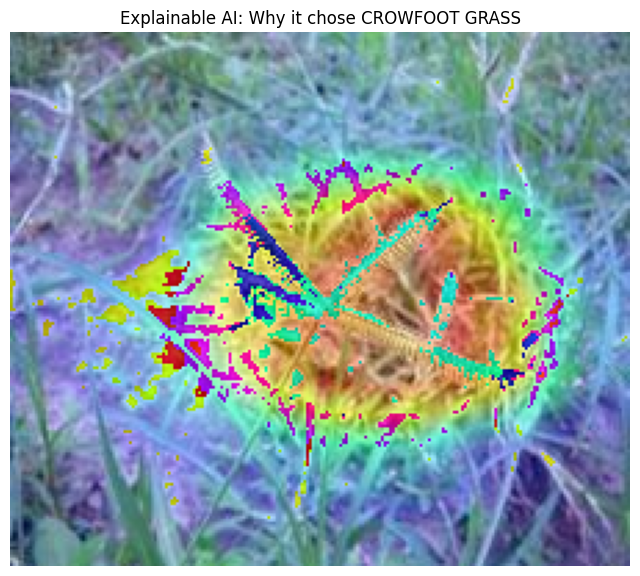

In [48]:
img_path = "/content/test.jpg"

print("Running Prediction & Farm Advisor Logic...")
label = predict_with_advice(img_path)

print("Generating Explainable AI Heatmap...")
get_gradcam(img_path)

In [45]:
from google.colab import files
uploaded_file = files.upload()

Saving 03e0ed29-50c9-4872-b174-8d8287b33cfa.jpeg to 03e0ed29-50c9-4872-b174-8d8287b33cfa.jpeg


In [49]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 32s 617ms/step - accuracy: 0.7290 - loss: 1.6628 - val_accuracy: 1.0000 - val_loss: 0.0242
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.7677 - loss: 1.4286 - val_accuracy: 1.0000 - val_loss: 0.0200
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.7935 - loss: 1.1218 - val_accuracy: 1.0000 - val_loss: 0.0175
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.7871 - loss: 0.9795 - val_accuracy: 1.0000 - val_loss: 0.0161
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.8323 - loss: 0.7639 - val_accuracy: 1.0000 - val_loss: 0.0153


In [50]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[callback])

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.8258 - loss: 0.6449 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step - accuracy: 0.8129 - loss: 0.5203 - val_accuracy: 1.0000 - val_loss: 0.0166
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.8516 - loss: 0.4552 - val_accuracy: 1.0000 - val_loss: 0.0187
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.9032 - loss: 0.3295 - val_accuracy: 1.0000 - val_loss: 0.0211


Gathering Predictions for Evaluation...



--- SKLEARN CLASSIFICATION REPORT ---
                    precision    recall  f1-score   support

CELOSIA ARGENTEA L       1.00      1.00      1.00         8
    CROWFOOT GRASS       1.00      1.00      1.00        17
    PURPLE CHLORIS       1.00      1.00      1.00        13

          accuracy                           1.00        38
         macro avg       1.00      1.00      1.00        38
      weighted avg       1.00      1.00      1.00        38



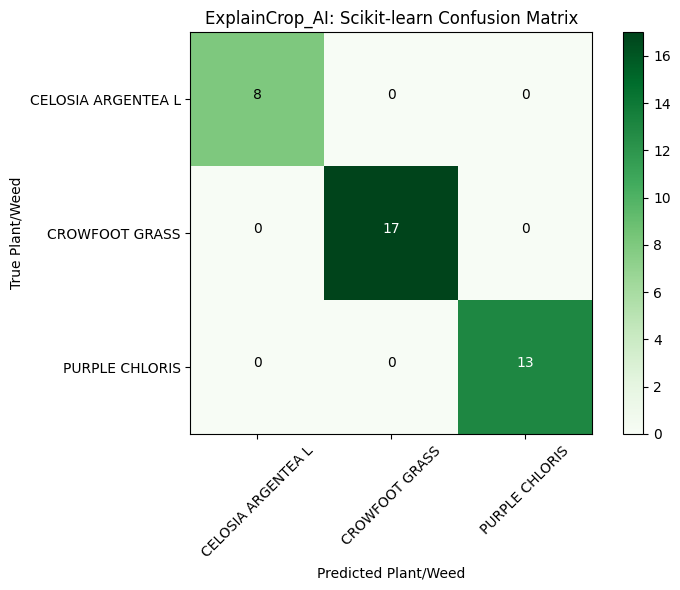

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print("Gathering Predictions for Evaluation...")

true_labels = []
predicted_labels = []

for images, labels in val_ds:
    true_labels.extend(labels.numpy())

    preds = model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(preds, axis=1))

print("\n--- SKLEARN CLASSIFICATION REPORT ---")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
plt.title('ExplainCrop_AI: Scikit-learn Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Plant/Weed')
plt.xlabel('Predicted Plant/Weed')
plt.tight_layout()
plt.show()

In [52]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0156
Validation Accuracy: 100.00%
